## Figure 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
os.chdir(r"D:\code\github\strainOptimizer")


In [2]:
# set the font size of the figure
plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1

axis_fontdict={'fontsize':9,'fontweight':'bold'}
label_fontdict={'fontsize':9,'fontweight':'bold'}
title_fontdict={'fontsize':12,'fontweight':'bold'}
legend_fontsize=9

# colors_set=sns.color_palette('colorblind')
colors_paired=sns.color_palette("Paired")
colors_compare=sns.color_palette('colorblind')
colors_paired
# colors_compare


[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

### Figure 1B. Comparison of Prediction Performance for ecGEM and EFL Strain Design

In [3]:
# load data
df_ecGEM_vs_EFL=pd.read_csv(r'analysis_code\results\ecGEM_vs_EFL_result.csv')

df_ecGEM_vs_EFL.head()

,model_type,product_name,level,consistency,precision,predict_num,average_distance,connectivity_score
0,ecGEM,2-phenylethanol,l1,0.692308,0.264706,34,6.433734,35.5
1,ecGEM,2-phenylethanol,l2,0.615385,0.320000,25,6.776974,35.0
2,ecGEM,2-phenylethanol,l3,0.384615,0.625000,8,6.268750,10.0
3,ecGEM,2-phenylethanol,fcc,0.384615,0.555556,9,6.096633,8.0
4,ecGEM,free fatty acids,l1,0.166667,0.055556,54,5.793753,5.0


C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\2209929908.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[4].set_xticklabels(['ecGEM','EFL'],fontsize=9,fontweight='bold')


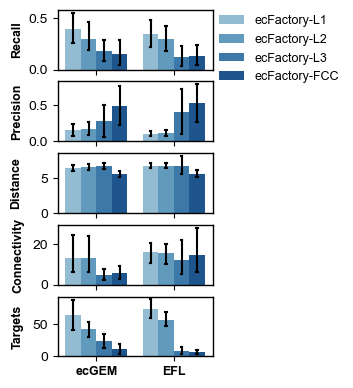

In [4]:
fig,axs=plt.subplots(5,1,figsize=(2,4.5))

platte=sns.color_palette('Blues')[2:]
# plot experiment constency
sns.barplot(x='model_type',y='consistency',hue='level',data=df_ecGEM_vs_EFL,ax=axs[0],capsize=0.1,err_kws={'linewidth':1.5,'color':'black'},palette=platte)
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',label_fontdict)
# set legend outside and content as : l1:ecFactory-L1, l2: ecFactory-L2, l3: ecFactory-L3, fcc: ecFactory-FCC
label_map = {
    'l1': 'ecFactory-L1',
    'l2': 'ecFactory-L2',
    'l3': 'ecFactory-L3',
    'fcc': 'ecFactory-FCC'
}
handles, labels = axs[0].get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.,
    fontsize=legend_fontsize,
    frameon=False
)

# plot experiment accuracy
sns.barplot(x='model_type',y='precision',hue='level',data=df_ecGEM_vs_EFL,ax=axs[1],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'},palette=platte)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',label_fontdict)


# plot average distance
sns.barplot(x='model_type',y='average_distance',hue='level',data=df_ecGEM_vs_EFL,ax=axs[2],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'},palette=platte)
axs[2].set_xlabel('')
axs[2].set_xticklabels([])
axs[2].set_ylabel('Distance',label_fontdict,labelpad=13)

# plot average connectivity
sns.barplot(ax=axs[3],x='model_type',y='connectivity_score',hue='level',data=df_ecGEM_vs_EFL,legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'},palette=platte)
axs[3].set_xlabel('')
axs[3].set_xticklabels([])
axs[3].set_ylabel('Connectivity',label_fontdict,labelpad=6)

# plot average predict numb
sns.barplot(ax=axs[4],x='model_type',y='predict_num',hue='level',data=df_ecGEM_vs_EFL,legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'},palette=platte)
axs[4].set_xlabel('')
axs[4].set_xticklabels(['ecGEM','EFL'],fontsize=9,fontweight='bold')
axs[4].set_ylabel('Targets',label_fontdict,labelpad=6)
# set title
# fig.suptitle('Evaluation of ecGEM and EFL')

# save figure
fig.savefig(r'analysis_code\figures\output/figure1b_ecGEM_vs_EFL.svg',dpi=600,bbox_inches='tight',transparent=True)

plt.show()

### Figure 1C. Statistical Relationship Between Predicted Target Count, Prediction Precision, and Experimental Consistency

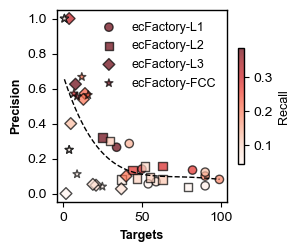

In [5]:
# plot the scatter plot
from cProfile import label


colore_consistency=df_ecGEM_vs_EFL['consistency'].tolist()
y_precision=df_ecGEM_vs_EFL['precision'].tolist()
size_num=df_ecGEM_vs_EFL['predict_num'].tolist()
color_level=df_ecGEM_vs_EFL['level'].tolist()

# color_map={'l1':'red','l2':'blue','l3':'green','fcc':'yellow'}
marker_map = {'l1': 'o', 'l2': 's', 'l3': 'D', 'fcc': '*'}  # 圆形/方形/菱形

marker_list=[marker_map[i] for i in color_level]
fig, ax = plt.subplots(figsize=(2.75,2.5))
for level,marker in marker_map.items():
    df_selected=df_ecGEM_vs_EFL[df_ecGEM_vs_EFL['level']==level]
    sc = ax.scatter(df_selected['predict_num'], df_selected['precision'], c=df_selected['consistency'],marker=marker, alpha=0.7, edgecolors='k',cmap='Reds',label=level)

# 拟合线（线性回归）
coef = np.polyfit(df_ecGEM_vs_EFL['predict_num'].values.astype(float), df_ecGEM_vs_EFL['precision'].values.astype(float), deg=4)   # 一次多项式
poly_fn = np.poly1d(coef)        # 生成拟合函数

x_line = np.linspace(min(df_ecGEM_vs_EFL['predict_num']), max(df_ecGEM_vs_EFL['predict_num']), 100)
y_line = poly_fn(x_line)
ax.plot(x_line, y_line, color="black", linewidth=1,linestyle='--')

# set colore bar
cbar = plt.colorbar(sc, ax=ax,shrink=0.6,location='right')
cbar.set_label("Recall",fontsize=9)

# set marker category
ax.legend(title="Category")
label_map = {
    'l1': 'ecFactory-L1',
    'l2': 'ecFactory-L2',
    'l3': 'ecFactory-L3',
    'fcc': 'ecFactory-FCC'
}
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
ax.legend(
    handles,
    new_labels,
    # title='Level',
    # bbox_to_anchor=(1.01, 1),
    # borderaxespad=0.
    fontsize=9,
    frameon=False
)


# set x, y label
ax.set_xlabel('Targets',label_fontdict)
ax.set_ylabel('Precision',label_fontdict)

# save figure
fig.savefig(r'analysis_code\figures\output/figure1c_precision_vs_predict_num.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Figure 1d. Comparison of Prediction Performance for ecGEM and EFL Strain Design in different product

C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\495784267.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\495784267.py:24: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\495784267.py:31: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\495784267.py:33: UserWarning: se

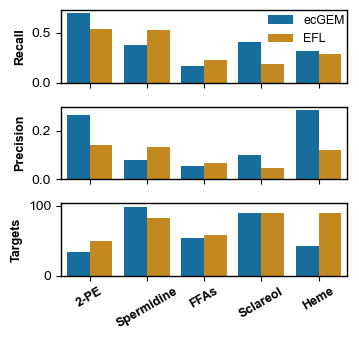

In [6]:
# for level in df_ecGEM_vs_EFL['level'].unique():
df_selected=df_ecGEM_vs_EFL[df_ecGEM_vs_EFL['level']=='l1']
productName_dict={'2-phenylethanol':'2-PE','spermidine':'Spermidine','free fatty acids':'FFAs','sclareol':'Sclareol','heme':'Heme'}
products_order=productName_dict.keys()
# set product order

# ['2-PE','FFAs','Heme a','Sclareol','Spermidine']
fig,axs=plt.subplots(3,1,figsize=(3.7,3.5))
# set title
# fig.suptitle(f'ecFactory-L1 level results',fontsize=16,fontweight='bold')
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',label_fontdict)
# set legend out 
axs[0].legend(title='Model type',
              bbox_to_anchor=(1.01, 1), 
              borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',label_fontdict)

# plot average distance
sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
axs[2].set_xlabel('')
axs[2].set_xticklabels([productName_dict[x.get_text()] for x in axs[2].get_xticklabels()],rotation=30,fontsize=9,fontweight='bold')
axs[2].set_ylabel('Targets',label_fontdict)

# rename legend label
handles, labels = axs[0].get_legend_handles_labels()
label_map={'ecGEM':'ecGEM','etfl':'EFL'}
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.,
    frameon=False,
    fontsize=9
)
plt.tight_layout()
# save result
fig.savefig(r'analysis_code\figures\output\figure1_products_ecGEM_vs_EFL-l1.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()


C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\3796924340.py:7: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\3796924340.py:17: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\3796924340.py:24: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\3796924340.py:26: UserWarning:

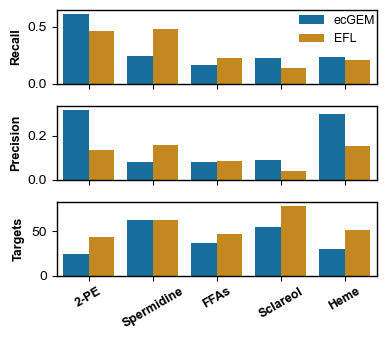

In [7]:
df_selected=df_ecGEM_vs_EFL[df_ecGEM_vs_EFL['level']=='l2']
# ['2-PE','FFAs','Heme a','Sclareol','Spermidine']
fig,axs=plt.subplots(3,1,figsize=(4,3.5))
# set title
# fig.suptitle(f'ecFactory-L2 level results',fontsize=12,fontweight='bold')
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',label_fontdict)
# set legend out 
axs[0].legend(title='Model type',bbox_to_anchor=(1.01, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',label_fontdict)

# plot average distance
sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
axs[2].set_xlabel('')
axs[2].set_xticklabels([productName_dict[x.get_text()] for x in axs[2].get_xticklabels()],rotation=30,fontsize=9,fontweight='bold')
axs[2].set_ylabel('Targets',label_fontdict,labelpad=5)

# rename legend label
handles, labels = axs[0].get_legend_handles_labels()
label_map={'ecGEM':'ecGEM','etfl':'EFL'}
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.,
    frameon=False,
    fontsize=9
)
plt.tight_layout()
# save result
fig.savefig(r'analysis_code\figures\output\figure1_products_ecGEM_vs_EFL-l2.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\252874411.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\252874411.py:19: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\252874411.py:26: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\252874411.py:28: UserWarning: set

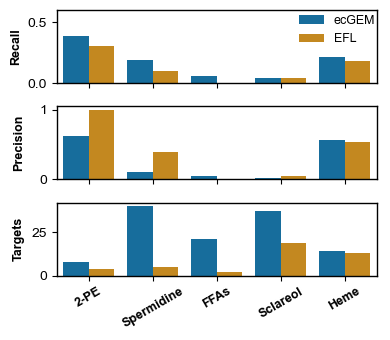

In [8]:
df_selected=df_ecGEM_vs_EFL[df_ecGEM_vs_EFL['level']=='l3']
# productName_dict={'2-phenylethanol':'2-PE','free fatty acids':'FFAs','heme':'Heme','sclareol':'Sclareol','spermidine':'Spermidine'}
# ['2-PE','FFAs','Heme a','Sclareol','Spermidine']
fig,axs=plt.subplots(3,1,figsize=(4,3.5))
# set title
# fig.suptitle(f'ecFactory-L3 level results',fontsize=12,fontweight='bold')
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',label_fontdict)
axs[0].set_ylim(0,0.6)
# set legend out 
axs[0].legend(title='Model type',bbox_to_anchor=(1.01, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',label_fontdict,labelpad=10)

# plot average distance
sns.barplot(x='product_name',y='predict_num',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
axs[2].set_xlabel('')
axs[2].set_xticklabels([productName_dict[x.get_text()] for x in axs[2].get_xticklabels()],rotation=30,fontsize=9,fontweight='bold')
axs[2].set_ylabel('Targets',label_fontdict,labelpad=5)

# rename legend label
handles, labels = axs[0].get_legend_handles_labels()
label_map={'ecGEM':'ecGEM','etfl':'EFL'}
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.,
    frameon=False,
    fontsize=9
)
plt.tight_layout()
# save result
fig.savefig(r'analysis_code\figures\output\figure1_products_ecGEM_vs_EFL-l3.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\987874502.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\987874502.py:20: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\987874502.py:27: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='average_distance',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
C:\Users\wangh\AppData\Local\Temp\ipykernel_28248\987874502.py:29: UserWarning

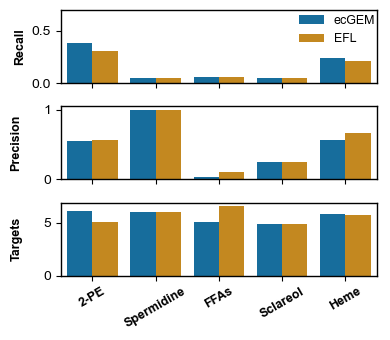

In [9]:
df_selected=df_ecGEM_vs_EFL[df_ecGEM_vs_EFL['level']=='fcc']
# productName_dict={'2-phenylethanol':'2-PE','free fatty acids':'FFAs','heme':'Heme','sclareol':'Sclareol','spermidine':'Spermidine'}
# ['2-PE','FFAs','Heme a','Sclareol','Spermidine']
fig,axs=plt.subplots(3,1,figsize=(4,3.5))
# set title
# fig.suptitle(f'FCC results',fontsize=12,fontweight='bold')
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='model_type',data=df_selected,ax=axs[0],palette=colors_compare,order=products_order)
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',label_fontdict)
axs[0].set_ylim(0,0.7)
# axs[0].set_ylim(0,0.5)
# set legend out 
# axs[0].legend(title='Model type',bbox_to_anchor=(5, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='model_type',data=df_selected,ax=axs[1],legend=False,palette=colors_compare,order=products_order)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',label_fontdict,labelpad=15)

# plot average distance
sns.barplot(x='product_name',y='average_distance',hue='model_type',data=df_selected,ax=axs[2],legend=False,palette=colors_compare,order=products_order)
axs[2].set_xlabel('')
axs[2].set_xticklabels([productName_dict[x.get_text()] for x in axs[2].get_xticklabels()],rotation=30,fontsize=9,fontweight='bold')
axs[2].set_ylabel('Targets',label_fontdict,labelpad=15)

# rename legend label
handles, labels = axs[0].get_legend_handles_labels()
label_map={'ecGEM':'ecGEM','etfl':'EFL'}
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
        frameon=False,
    borderaxespad=0,
    fontsize=9
)
plt.tight_layout()
# save result
fig.savefig(r'analysis_code\figures\output\figure1_products_ecGEM_vs_EFL-fcc.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Figure 1E. Compare the ecGEM and EFL predict targets differnece